
# ITAI 2277 Phase Two — DrugBank Feature Engineering (Clean Final Notebook)

This notebook is a cleaned, end-to-end version of the DrugBank preprocessing and feature engineering workflow for **CompoundIQ Task 3**.

## Task 3 goals
- Add molecular similarity features
- Create network graph features (**degree centrality**, **betweenness**)
- Verify CYP enzyme feature quality
- Add interaction severity categories when possible
- Re-save the enhanced DrugBank feature table

## Main outputs
- `drugs.parquet`
- `drug_interactions.parquet`
- `targets.parquet`
- `enzymes.parquet`
- `drugs_ml.parquet`
- `graph_features.parquet`
- `cyp_features.parquet`
- `severity_features.parquet`
- `similarity_features.parquet`
- `drugbank_processed_enhanced.parquet`
- `train_features.parquet`, `val_features.parquet`, `test_features.parquet`

> This version keeps the original XML parsing workflow, removes duplicate/debug-only cells, and adds the missing Task 3 feature blocks in a single notebook.


## 1. Mount Drive and set paths

In [1]:

from google.colab import drive
drive.mount("/content/drive")

# Update these paths only if your Drive folder is different
INPUT_XML = "/content/drive/MyDrive/ITAI2277DrugBank/drugbank_full.xml"
OUT_DIR   = "/content/drive/MyDrive/ITAI2277DrugBank/derived_tables"


Mounted at /content/drive


## 2. Install dependencies

In [2]:
!pip -q install lxml pyarrow fastparquet tqdm networkx rdkit scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 41.3 MB/s eta 0:00:00



## 3. Stream-parse DrugBank XML into compact tables

This step creates four aligned tables:
- `drugs`
- `drug_interactions`
- `targets`
- `enzymes`

The parsing code is intentionally chunked so it can run in Colab without loading the full XML into memory at once.


In [3]:
import os, re
from lxml import etree
from tqdm import tqdm
import pandas as pd

os.makedirs(OUT_DIR, exist_ok=True)

# Flush in chunks to keep memory low
FLUSH_EVERY = 5000

# DrugBank XML usually uses this namespace:
DB_NS = "http://www.drugbank.ca"
NS = {"db": DB_NS}

def strip_ws(s):
    if s is None:
        return None
    s = re.sub(r"\s+", " ", s).strip()
    return s if s else None

def findtext(elem, xpath, default=None):
    try:
        v = elem.findtext(xpath, namespaces=NS)
        v = strip_ws(v)
        return v if v is not None else default
    except Exception:
        return default

def findall(elem, xpath):
    try:
        return elem.findall(xpath, namespaces=NS)
    except Exception:
        return []

def get_primary_drugbank_id(drug_elem):
    ids = findall(drug_elem, "db:drugbank-id")
    for i in ids:
        if i.get("primary") == "true":
            return strip_ws(i.text)
    return strip_ws(ids[0].text) if ids else None

def extract_calculated_property(drug_elem, kind_name: str):
    for prop in findall(drug_elem, "db:calculated-properties/db:property"):
        kind = findtext(prop, "db:kind")
        if kind and kind.lower() == kind_name.lower():
            return findtext(prop, "db:value")
    return None

def flush_parquet(rows, path):
    if not rows:
        return
    pd.DataFrame(rows).to_parquet(path, index=False)

# Output chunk files
def part_path(prefix, idx):
    return os.path.join(OUT_DIR, f"{prefix}_part_{idx:03d}.parquet")

drug_rows, ddi_rows, target_rows, enzyme_rows = [], [], [], []
drug_part = ddi_part = targ_part = enz_part = 0
n_drugs = 0

context = etree.iterparse(
    INPUT_XML,
    events=("end",),
    tag=f"{{{DB_NS}}}drug",
    huge_tree=True,
    recover=True
)

for event, drug in tqdm(context, desc="Streaming DrugBank <drug>"):
    n_drugs += 1
    drug_id = get_primary_drugbank_id(drug)
    if not drug_id:
        drug.clear()
        continue

    # ---------- DRUG CORE ----------
    name = findtext(drug, "db:name")
    drug_type = drug.get("type")  # attribute often exists
    groups = [findtext(g, ".") for g in findall(drug, "db:groups/db:group")]
    groups = [g for g in groups if g]

    smiles = extract_calculated_property(drug, "SMILES")
    inchi = extract_calculated_property(drug, "InChI")
    inchikey = extract_calculated_property(drug, "InChIKey")

    # These two are often very large text; keep for now, you can drop later to reduce size
    description = findtext(drug, "db:description")
    indication_text = findtext(drug, "db:indication")

    drug_rows.append({
        "drugbank_id": drug_id,
        "name": name,
        "type": drug_type,
        "groups": groups,
        "smiles": smiles,
        "inchi": inchi,
        "inchikey": inchikey,
        "description": description,
        "indication_text": indication_text,
    })

    # ---------- DRUG-DRUG INTERACTIONS ----------
    for di in findall(drug, "db:drug-interactions/db:drug-interaction"):
        affected_id = findtext(di, "db:drugbank-id") or findtext(di, "db:affected-drugbank-id")
        affected_name = findtext(di, "db:name") or findtext(di, "db:affected-name")
        ddi_desc = findtext(di, "db:description")

        # These fields may not exist in the XML dump; keep as optional columns.
        severity = findtext(di, "db:severity")
        evidence_level = findtext(di, "db:evidence-level") or findtext(di, "db:evidence_level")
        action = findtext(di, "db:action")
        management = findtext(di, "db:management")

        if affected_id or affected_name or ddi_desc:
            ddi_rows.append({
                "subject_drugbank_id": drug_id,
                "subject_name": name,
                "affected_drugbank_id": affected_id,
                "affected_name": affected_name,
                "description": ddi_desc,
                "severity": severity,
                "evidence_level": evidence_level,
                "action": action,
                "management": management,
            })

    # ---------- TARGETS ----------
    for t in findall(drug, "db:targets/db:target"):
        target_rows.append({
            "drugbank_id": drug_id,
            "drug_name": name,
            "target_id": findtext(t, "db:id"),
            "target_name": findtext(t, "db:name"),
            "organism": findtext(t, "db:organism"),
            "actions": [findtext(a, ".") for a in findall(t, "db:actions/db:action") if findtext(a, ".")],
            "uniprot_id": findtext(t, "db:polypeptide/db:external-identifiers/db:external-identifier[db:resource='UniProtKB']/db:identifier"),
        })

    # ---------- ENZYMES (CYP) ----------
    for e in findall(drug, "db:enzymes/db:enzyme"):
        enzyme_rows.append({
            "drugbank_id": drug_id,
            "drug_name": name,
            "enzyme_id": findtext(e, "db:id"),
            "enzyme_name": findtext(e, "db:name"),
            "organism": findtext(e, "db:organism"),
            "actions": [findtext(a, ".") for a in findall(e, "db:actions/db:action") if findtext(a, ".")],
            "uniprot_id": findtext(e, "db:polypeptide/db:external-identifiers/db:external-identifier[db:resource='UniProtKB']/db:identifier"),
        })

    # ---------- Flush chunks ----------
    if len(drug_rows) >= FLUSH_EVERY:
        flush_parquet(drug_rows, part_path("drugs", drug_part))
        drug_rows.clear(); drug_part += 1

    if len(ddi_rows) >= FLUSH_EVERY:
        flush_parquet(ddi_rows, part_path("ddi", ddi_part))
        ddi_rows.clear(); ddi_part += 1

    if len(target_rows) >= FLUSH_EVERY:
        flush_parquet(target_rows, part_path("targets", targ_part))
        target_rows.clear(); targ_part += 1

    if len(enzyme_rows) >= FLUSH_EVERY:
        flush_parquet(enzyme_rows, part_path("enzymes", enz_part))
        enzyme_rows.clear(); enz_part += 1

    # ---------- CRITICAL: free XML memory ----------
    drug.clear()
    while drug.getprevious() is not None:
        del drug.getparent()[0]

# Final flush
if drug_rows: flush_parquet(drug_rows, part_path("drugs", drug_part))
if ddi_rows: flush_parquet(ddi_rows, part_path("ddi", ddi_part))
if target_rows: flush_parquet(target_rows, part_path("targets", targ_part))
if enzyme_rows: flush_parquet(enzyme_rows, part_path("enzymes", enz_part))

print("DONE. Parsed drugs:", n_drugs)
print("Chunk files saved in:", OUT_DIR)


Streaming DrugBank <drug>: 1014328it [08:39, 1950.97it/s]


DONE. Parsed drugs: 1014328
Chunk files saved in: /content/drive/MyDrive/ITAI2277DrugBank/derived_tables


## 4. Merge chunk files into final parquet tables

In [4]:

import glob
import os
import pandas as pd

def merge_parts(prefix, final_name):
    paths = sorted(glob.glob(os.path.join(OUT_DIR, f"{prefix}_part_*.parquet")))
    if not paths:
        print(f"No chunk files found for prefix: {prefix}")
        return pd.DataFrame()

    dfs = [pd.read_parquet(p) for p in paths]
    df = pd.concat(dfs, ignore_index=True)
    out = os.path.join(OUT_DIR, final_name)
    df.to_parquet(out, index=False)
    print(f"{final_name}: rows={len(df):,}  size={os.path.getsize(out)/1024/1024:.2f} MB")
    return df

drugs   = merge_parts("drugs",   "drugs.parquet")
ddi     = merge_parts("ddi",     "drug_interactions.parquet")
targets = merge_parts("targets", "targets.parquet")
enzymes = merge_parts("enzymes", "enzymes.parquet")


drugs.parquet: rows=1,014,328  size=5.31 MB
drug_interactions.parquet: rows=2,910,010  size=55.14 MB
targets.parquet: rows=24,231  size=0.56 MB
enzymes.parquet: rows=6,062  size=0.08 MB


## 5. Build a compact ML-ready drug table

In [5]:

import os
import numpy as np
import pandas as pd

drugs = pd.read_parquet(os.path.join(OUT_DIR, "drugs.parquet"))

# Keep long text separately
meta_cols = ["drugbank_id", "description", "indication_text"]
drug_meta = drugs[[c for c in meta_cols if c in drugs.columns]].copy()
drug_meta.to_parquet(os.path.join(OUT_DIR, "drugs_text_metadata.parquet"), index=False)

# Compact modeling table
drugs_ml = drugs.drop(columns=["description", "indication_text"], errors="ignore").copy()

def safe_groups_to_string(x):
    if x is None:
        return ""
    if isinstance(x, (list, tuple, np.ndarray)):
        return ",".join([str(i) for i in x if pd.notna(i)])
    if pd.isna(x):
        return ""
    return str(x)

if "groups" in drugs_ml.columns:
    drugs_ml["groups"] = drugs_ml["groups"].apply(safe_groups_to_string)

def first_nonnull(series):
    s = series.dropna()
    s = s[s.astype(str).str.strip() != ""]
    return s.iloc[0] if len(s) else None

agg_map = {c: first_nonnull for c in drugs_ml.columns if c != "drugbank_id"}
drugs_ml_1 = drugs_ml.groupby("drugbank_id", as_index=False).agg(agg_map)

drugs_ml.to_parquet(os.path.join(OUT_DIR, "drugs_ml.parquet"), index=False)
drugs_ml_1.to_parquet(os.path.join(OUT_DIR, "drugs_ml_1row.parquet"), index=False)

print("drugs shape:", drugs.shape)
print("drugs_ml shape:", drugs_ml.shape)
print("drugs_ml_1 shape:", drugs_ml_1.shape)
print("Duplicate drugbank_id values after collapse:", drugs_ml_1["drugbank_id"].duplicated().sum())


drugs shape: (1014328, 9)
drugs_ml shape: (1014328, 7)
drugs_ml_1 shape: (19830, 7)
Duplicate drugbank_id values after collapse: 0



## 6. Graph features from the drug–drug interaction network

This section builds:
- interaction count features
- unique partner counts
- graph centrality features:
  - `degree_centrality`
  - `betweenness_centrality`

For large graphs, betweenness is approximated with node sampling to keep runtime reasonable in Colab.


In [6]:

import os
import numpy as np
import pandas as pd
import networkx as nx

ddi = pd.read_parquet(os.path.join(OUT_DIR, "drug_interactions.parquet")).copy()

# Standardize identifiers
for col in ["subject_drugbank_id", "affected_drugbank_id"]:
    ddi[col] = ddi[col].astype(str).str.strip()

ddi = ddi[
    ddi["subject_drugbank_id"].notna() &
    ddi["affected_drugbank_id"].notna() &
    (ddi["subject_drugbank_id"] != "") &
    (ddi["affected_drugbank_id"] != "")
].copy()

# Remove self-loops for graph analysis
ddi_graph = ddi[ddi["subject_drugbank_id"] != ddi["affected_drugbank_id"]].copy()

# Directed interaction count features
out_degree = (
    ddi_graph.groupby("subject_drugbank_id")
    .size()
    .reset_index(name="n_interactions_as_subject")
)

in_degree = (
    ddi_graph.groupby("affected_drugbank_id")
    .size()
    .reset_index(name="n_interactions_as_affected")
)

tmp = out_degree.merge(
    in_degree,
    left_on="subject_drugbank_id",
    right_on="affected_drugbank_id",
    how="outer"
)

tmp["drugbank_id"] = tmp["subject_drugbank_id"].combine_first(tmp["affected_drugbank_id"])
tmp["n_interactions_as_subject"] = tmp["n_interactions_as_subject"].fillna(0).astype("int64")
tmp["n_interactions_as_affected"] = tmp["n_interactions_as_affected"].fillna(0).astype("int64")
tmp["total_interactions"] = tmp["n_interactions_as_subject"] + tmp["n_interactions_as_affected"]

degree_features = tmp[[
    "drugbank_id",
    "n_interactions_as_subject",
    "n_interactions_as_affected",
    "total_interactions"
]].copy()

# Unique partner count using an undirected pair table
pairs = ddi_graph[["subject_drugbank_id", "affected_drugbank_id"]].copy()
pairs["a"] = pairs[["subject_drugbank_id", "affected_drugbank_id"]].min(axis=1)
pairs["b"] = pairs[["subject_drugbank_id", "affected_drugbank_id"]].max(axis=1)
pairs = pairs[["a", "b"]].drop_duplicates()

partner_counts = pd.concat([
    pairs.rename(columns={"a": "drugbank_id", "b": "partner_id"})[["drugbank_id", "partner_id"]],
    pairs.rename(columns={"b": "drugbank_id", "a": "partner_id"})[["drugbank_id", "partner_id"]],
], ignore_index=True)

partner_features = (
    partner_counts.groupby("drugbank_id")["partner_id"]
    .nunique()
    .reset_index(name="n_unique_interaction_partners")
)

# Build graph
G = nx.Graph()
G.add_edges_from(pairs[["a", "b"]].itertuples(index=False, name=None))

degree_centrality = pd.DataFrame(
    list(nx.degree_centrality(G).items()),
    columns=["drugbank_id", "degree_centrality"]
)

n_nodes = G.number_of_nodes()
if n_nodes <= 2500:
    bet = nx.betweenness_centrality(G, normalized=True)
    betweenness = pd.DataFrame(list(bet.items()), columns=["drugbank_id", "betweenness_centrality"])
    print(f"Computed exact betweenness on {n_nodes:,} nodes.")
else:
    k = min(250, max(50, n_nodes // 20))
    bet = nx.betweenness_centrality(G, k=k, normalized=True, seed=42)
    betweenness = pd.DataFrame(list(bet.items()), columns=["drugbank_id", "betweenness_centrality"])
    print(f"Computed approximate betweenness on {n_nodes:,} nodes using k={k} sampled nodes.")

graph_features = (
    degree_features
    .merge(partner_features, on="drugbank_id", how="outer")
    .merge(degree_centrality, on="drugbank_id", how="outer")
    .merge(betweenness, on="drugbank_id", how="outer")
)

for col in ["n_interactions_as_subject", "n_interactions_as_affected", "total_interactions", "n_unique_interaction_partners"]:
    if col in graph_features.columns:
        graph_features[col] = graph_features[col].fillna(0).astype("int64")

for col in ["degree_centrality", "betweenness_centrality"]:
    if col in graph_features.columns:
        graph_features[col] = graph_features[col].fillna(0.0)

graph_features["drugbank_id"] = graph_features["drugbank_id"].astype(str)
graph_features.to_parquet(os.path.join(OUT_DIR, "graph_features.parquet"), index=False)

print("graph_features shape:", graph_features.shape)
display(graph_features.sort_values("degree_centrality", ascending=False).head(10))


Computed approximate betweenness on 4,629 nodes using k=231 sampled nodes.
graph_features shape: (4629, 7)


,drugbank_id,n_interactions_as_subject,n_interactions_as_affected,total_interactions,n_unique_interaction_partners,degree_centrality,betweenness_centrality
301,DB00363,2636,2636,5272,2636,0.569576,0.002421
408,DB00477,2535,2534,5069,2535,0.547753,0.001971
262,DB00321,2458,2458,4916,2458,0.531115,0.001549
392,DB00458,2455,2455,4910,2455,0.530467,0.001633
487,DB00564,2423,2423,4846,2423,0.523552,0.004889
73,DB00091,2401,2400,4801,2401,0.518799,0.003429
814,DB00908,2391,2391,4782,2391,0.516638,0.002331
1038,DB01142,2384,2384,4768,2384,0.515125,0.001522
726,DB00814,2381,2380,4761,2381,0.514477,0.010375
1133,DB01242,2366,2366,4732,2366,0.511236,0.001256



## 7. CYP enzyme feature engineering and quality verification

This block:
- normalizes enzyme names
- identifies CYP-related records
- extracts CYP family tokens when possible
- aggregates per-drug CYP features
- adds simple quality checks


In [7]:

import os
import re
import numpy as np
import pandas as pd

enz = pd.read_parquet(os.path.join(OUT_DIR, "enzymes.parquet")).copy()
enz["drugbank_id"] = enz["drugbank_id"].astype(str)

enz["enzyme_name_clean"] = (
    enz["enzyme_name"]
    .astype(str)
    .str.upper()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Detect both formats: CYP3A4 and CYTOCHROME P450 3A4
enz["is_cyp"] = enz["enzyme_name_clean"].str.contains(r"CYP|CYTOCHROME P450", regex=True, na=False)

# Extract CYP token when it exists directly
enz["cyp_token"] = enz["enzyme_name_clean"].str.extract(r"(CYP[0-9][A-Z0-9]*)", expand=False)

# Recover token from "CYTOCHROME P450 3A4" style names
mask = enz["cyp_token"].isna() & enz["is_cyp"]
enz.loc[mask, "cyp_token"] = (
    enz.loc[mask, "enzyme_name_clean"]
    .str.extract(r"CYTOCHROME P450\s*([0-9][A-Z0-9]*)", expand=False)
    .apply(lambda x: f"CYP{x}" if pd.notna(x) else None)
)

total_enzyme_records = enz.groupby("drugbank_id").size().reset_index(name="n_enzyme_records")
cyp_counts = enz.groupby("drugbank_id")["is_cyp"].sum().reset_index(name="n_cyp_records")

unique_cyp = (
    enz[enz["is_cyp"] & enz["cyp_token"].notna()]
    .groupby("drugbank_id")["cyp_token"]
    .nunique()
    .reset_index(name="n_unique_cyp")
)

quality_stats = (
    enz.assign(cyp_token_found=enz["cyp_token"].notna().astype(int))
    .groupby("drugbank_id")
    .agg(
        pct_cyp_records_with_token=("cyp_token_found", "mean"),
        n_missing_enzyme_names=("enzyme_name_clean", lambda s: int((s == "NONE").sum()) if len(s) else 0),
    )
    .reset_index()
)

cyp_features = (
    total_enzyme_records
    .merge(cyp_counts, on="drugbank_id", how="outer")
    .merge(unique_cyp, on="drugbank_id", how="outer")
    .merge(quality_stats, on="drugbank_id", how="outer")
)

for col in ["n_enzyme_records", "n_cyp_records", "n_unique_cyp", "n_missing_enzyme_names"]:
    cyp_features[col] = cyp_features[col].fillna(0).astype("int64")

cyp_features["pct_cyp_records_with_token"] = cyp_features["pct_cyp_records_with_token"].fillna(0.0)
cyp_features["has_cyp_info"] = (cyp_features["n_cyp_records"] > 0).astype("int64")

cyp_features.to_parquet(os.path.join(OUT_DIR, "cyp_features.parquet"), index=False)

print("cyp_features shape:", cyp_features.shape)
print("\nQuick CYP quality summary:")
display(cyp_features[[
    "n_enzyme_records", "n_cyp_records", "n_unique_cyp",
    "pct_cyp_records_with_token", "has_cyp_info"
]].describe())


cyp_features shape: (1869, 7)

Quick CYP quality summary:


,n_enzyme_records,n_cyp_records,n_unique_cyp,pct_cyp_records_with_token,has_cyp_info
count,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000
mean,3.243446,2.285179,2.276619,0.695653,0.793472
std,3.093496,2.450254,2.450144,0.407902,0.404922
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,0.333333,1.000000
50%,2.000000,1.000000,1.000000,1.000000,1.000000
75%,4.000000,3.000000,3.000000,1.000000,1.000000
max,24.000000,14.000000,14.000000,1.000000,1.000000



## 8. Interaction severity features

DrugBank interaction severity fields are not always present in the XML dump.  
This section uses:
1. explicit `severity` when available
2. rule-based keyword extraction from the interaction description otherwise

The output is aggregated per subject drug.


In [8]:

import os
import numpy as np
import pandas as pd

ddi = pd.read_parquet(os.path.join(OUT_DIR, "drug_interactions.parquet")).copy()
ddi["subject_drugbank_id"] = ddi["subject_drugbank_id"].astype(str)

severity_col_available = "severity" in ddi.columns

def derive_severity(row):
    # Prefer explicit severity if present
    if severity_col_available:
        sev = str(row.get("severity", "")).strip().lower()
        if sev and sev not in {"nan", "none"}:
            return sev

    text = str(row.get("description", "")).lower()

    severe_terms = [
        "contraindicated", "major", "life-threatening", "fatal", "serious", "significantly increase"
    ]
    moderate_terms = [
        "moderate", "increase", "decrease", "reduce", "enhance", "monitor closely", "dose adjustment"
    ]
    mild_terms = [
        "minor", "mild", "may", "can", "possible", "risk may be increased"
    ]

    if any(term in text for term in severe_terms):
        return "severe"
    if any(term in text for term in moderate_terms):
        return "moderate"
    if any(term in text for term in mild_terms):
        return "mild"
    return "unknown"

ddi["severity_category"] = ddi.apply(derive_severity, axis=1)

severity_map = {
    "unknown": 0,
    "mild": 1,
    "moderate": 2,
    "major": 3,
    "severe": 3
}
ddi["severity_score"] = ddi["severity_category"].map(severity_map).fillna(0).astype(int)

severity_features = (
    ddi.groupby("subject_drugbank_id")
    .agg(
        severity_mean=("severity_score", "mean"),
        severity_max=("severity_score", "max"),
        n_severe_interactions=("severity_score", lambda s: int((s >= 3).sum())),
        n_moderate_interactions=("severity_score", lambda s: int((s == 2).sum())),
        n_mild_interactions=("severity_score", lambda s: int((s == 1).sum())),
    )
    .reset_index()
    .rename(columns={"subject_drugbank_id": "drugbank_id"})
)

severity_features.to_parquet(os.path.join(OUT_DIR, "severity_features.parquet"), index=False)

print("severity_features shape:", severity_features.shape)
display(ddi["severity_category"].value_counts(dropna=False).to_frame("count"))


severity_features shape: (4628, 6)


,count
severity_category,
moderate,2910010



## 9. Molecular similarity features

To keep runtime practical in Colab, this notebook computes similarity to a **reference panel** rather than all-vs-all similarity.

Reference panel strategy:
- use valid SMILES only
- prioritize drugs with the highest interaction counts
- compute Morgan fingerprints
- add summary similarity features:
  - `mean_similarity_to_reference`
  - `max_similarity_to_reference`
  - `n_reference_neighbors_ge_0_7`

This satisfies the Task 3 requirement while staying computationally realistic.


In [9]:
import os
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

drugs_ml_1 = pd.read_parquet(os.path.join(OUT_DIR, "drugs_ml_1row.parquet")).copy()
graph_features = pd.read_parquet(os.path.join(OUT_DIR, "graph_features.parquet")).copy()

drugs_sim = drugs_ml_1.merge(
    graph_features[["drugbank_id", "total_interactions"]],
    on="drugbank_id",
    how="left"
)

drugs_sim["total_interactions"] = drugs_sim["total_interactions"].fillna(0)
drugs_sim["smiles"] = drugs_sim["smiles"].astype(str).replace({"nan": None, "None": None})

def mol_from_smiles(smiles):
    if smiles is None or pd.isna(smiles) or str(smiles).strip() == "":
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None

drugs_sim["mol"] = drugs_sim["smiles"].apply(mol_from_smiles)
drugs_sim["has_valid_smiles"] = drugs_sim["mol"].notna().astype(int)

valid = drugs_sim[drugs_sim["mol"].notna()].copy()

def make_fp(mol, radius=2, nbits=1024):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)

valid["fp"] = valid["mol"].apply(make_fp)

REFERENCE_SIZE = min(200, len(valid))
reference = (
    valid.sort_values(["total_interactions", "drugbank_id"], ascending=[False, True])
    .head(REFERENCE_SIZE)
    .copy()
)

reference_fps = reference["fp"].tolist()

def similarity_summary(fp, ref_fps):
    if not ref_fps:
        return pd.Series({
            "mean_similarity_to_reference": np.nan,
            "max_similarity_to_reference": np.nan,
            "n_reference_neighbors_ge_0_7": 0
        })
    sims = DataStructs.BulkTanimotoSimilarity(fp, ref_fps)
    return pd.Series({
        "mean_similarity_to_reference": float(np.mean(sims)),
        "max_similarity_to_reference": float(np.max(sims)),
        "n_reference_neighbors_ge_0_7": int(np.sum(np.array(sims) >= 0.7))
    })

sim_features = valid[["drugbank_id"]].copy()
sim_summary = valid["fp"].apply(lambda fp: similarity_summary(fp, reference_fps))
sim_features = pd.concat([sim_features.reset_index(drop=True), sim_summary.reset_index(drop=True)], axis=1)

similarity_features = drugs_ml_1[["drugbank_id"]].merge(sim_features, on="drugbank_id", how="left")
similarity_features["has_valid_smiles"] = drugs_ml_1["drugbank_id"].map(
    valid.set_index("drugbank_id")["has_valid_smiles"]
).fillna(0).astype(int)

for col in ["mean_similarity_to_reference", "max_similarity_to_reference"]:
    similarity_features[col] = similarity_features[col].fillna(0.0)

similarity_features["n_reference_neighbors_ge_0_7"] = (
    similarity_features["n_reference_neighbors_ge_0_7"].fillna(0).astype(int)
)

similarity_features.to_parquet(os.path.join(OUT_DIR, "similarity_features.parquet"), index=False)

print("similarity_features shape:", similarity_features.shape)
print("Valid SMILES count:", int(similarity_features["has_valid_smiles"].sum()))
display(similarity_features.head())

Streaming output truncated to the last 5000 lines.
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:22:19] DEPRECATION WARNING: please use MorganGenerator
[20:2

similarity_features shape: (19830, 5)
Valid SMILES count: 14606


,drugbank_id,mean_similarity_to_reference,max_similarity_to_reference,n_reference_neighbors_ge_0_7,has_valid_smiles
0,DB00001,0.0,0.0,0,0
1,DB00002,0.0,0.0,0,0
2,DB00003,0.0,0.0,0,0
3,DB00004,0.0,0.0,0,0
4,DB00005,0.0,0.0,0,0



## 10. Final merge into the enhanced DrugBank feature table

This final table merges:
- compact drug metadata
- graph features
- CYP features
- severity features
- molecular similarity features

It also computes an updated `safety_complexity_score`.


In [10]:

import os
import numpy as np
import pandas as pd

drugs_ml_1 = pd.read_parquet(os.path.join(OUT_DIR, "drugs_ml_1row.parquet")).copy()
graph_features = pd.read_parquet(os.path.join(OUT_DIR, "graph_features.parquet")).copy()
cyp_features = pd.read_parquet(os.path.join(OUT_DIR, "cyp_features.parquet")).copy()
severity_features = pd.read_parquet(os.path.join(OUT_DIR, "severity_features.parquet")).copy()
similarity_features = pd.read_parquet(os.path.join(OUT_DIR, "similarity_features.parquet")).copy()

for df in [drugs_ml_1, graph_features, cyp_features, severity_features, similarity_features]:
    df["drugbank_id"] = df["drugbank_id"].astype(str)

features = (
    drugs_ml_1
    .merge(graph_features, on="drugbank_id", how="left", validate="one_to_one")
    .merge(cyp_features, on="drugbank_id", how="left", validate="one_to_one")
    .merge(severity_features, on="drugbank_id", how="left", validate="one_to_one")
    .merge(similarity_features, on="drugbank_id", how="left", validate="one_to_one")
)

fill_zero_int = [
    "n_interactions_as_subject",
    "n_interactions_as_affected",
    "total_interactions",
    "n_unique_interaction_partners",
    "n_enzyme_records",
    "n_cyp_records",
    "n_unique_cyp",
    "n_missing_enzyme_names",
    "has_cyp_info",
    "n_severe_interactions",
    "n_moderate_interactions",
    "n_mild_interactions",
    "n_reference_neighbors_ge_0_7",
    "has_valid_smiles",
]

fill_zero_float = [
    "degree_centrality",
    "betweenness_centrality",
    "pct_cyp_records_with_token",
    "severity_mean",
    "severity_max",
    "mean_similarity_to_reference",
    "max_similarity_to_reference",
]

for col in fill_zero_int:
    if col in features.columns:
        features[col] = features[col].fillna(0).astype("int64")

for col in fill_zero_float:
    if col in features.columns:
        features[col] = features[col].fillna(0.0)

# Updated safety complexity score
features["safety_complexity_score"] = (
    np.log1p(features["total_interactions"]) +
    0.75 * features["n_unique_cyp"] +
    1.50 * features["severity_mean"] +
    2.00 * features["betweenness_centrality"] +
    0.50 * features["max_similarity_to_reference"]
)

final_path = os.path.join(OUT_DIR, "drugbank_processed_enhanced.parquet")
features.to_parquet(final_path, index=False)

print("Saved:", final_path)
print("features shape:", features.shape)
print("unique drugbank_id:", features["drugbank_id"].nunique())
print("duplicate drugbank_id:", features["drugbank_id"].duplicated().sum())

display(
    features.sort_values("safety_complexity_score", ascending=False)[[
        "drugbank_id", "name", "total_interactions", "n_unique_cyp",
        "degree_centrality", "betweenness_centrality",
        "severity_mean", "max_similarity_to_reference",
        "safety_complexity_score"
    ]].head(10)
)


Saved: /content/drive/MyDrive/ITAI2277DrugBank/derived_tables/drugbank_processed_enhanced.parquet
features shape: (19830, 29)
unique drugbank_id: 19830
duplicate drugbank_id: 0


,drugbank_id,name,total_interactions,n_unique_cyp,degree_centrality,betweenness_centrality,severity_mean,max_similarity_to_reference,safety_complexity_score
8172,DB09061,Cannabidiol,3636,14,0.392826,0.000523,2.0,1.000000,22.199961
1009,DB01026,Ketoconazole,3034,14,0.327787,0.000506,2.0,0.252525,21.645241
241,DB00252,Phenytoin,4073,13,0.440147,0.003395,2.0,1.000000,21.569170
1154,DB01174,Phenobarbital,3884,13,0.419620,0.002452,2.0,1.000000,21.519783
12064,DB14009,Medical Cannabis,2356,14,0.254538,0.000202,2.0,0.000000,21.265549
659,DB00675,Tamoxifen,3004,13,0.324546,0.000526,2.0,0.363636,20.940903
12773,DB14737,Cannabinol,2422,13,0.261668,0.000148,2.0,0.322581,20.704347
1214,DB01234,Dexamethasone,3510,12,0.379213,0.001749,2.0,1.000000,20.667154
457,DB00470,Dronabinol,2896,12,0.312878,0.000274,2.0,0.571429,20.257693
12685,DB14649,Dexamethasone acetate,2162,12,0.233578,0.000402,2.0,0.793651,20.076881


## 11. Focused active-feature subset for EDA and modeling

In [11]:

features_active = features[
    (features["total_interactions"] > 0) |
    (features["n_unique_cyp"] > 0) |
    (features["severity_max"] > 0)
].copy()

features["has_interactions"] = (features["total_interactions"] > 0).astype(int)
features["has_cyp"] = (features["n_unique_cyp"] > 0).astype(int)

print("features shape:", features.shape)
print("features_active shape:", features_active.shape)

display(features_active[[
    "total_interactions",
    "n_unique_cyp",
    "degree_centrality",
    "betweenness_centrality",
    "severity_mean",
    "max_similarity_to_reference",
    "safety_complexity_score"
]].describe())


features shape: (19830, 31)
features_active shape: (4657, 29)


,total_interactions,n_unique_cyp,degree_centrality,betweenness_centrality,severity_mean,max_similarity_to_reference,safety_complexity_score
count,4657.000000,4657.000000,4657.000000,4.657000e+03,4657.000000,4657.000000,4657.000000
mean,1249.619498,0.913678,0.135019,2.248057e-04,1.987546,0.263217,10.149124
std,1066.190746,1.911559,0.115198,6.521459e-04,0.157350,0.229676,2.662950
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.750000
25%,252.000000,0.000000,0.027226,4.645715e-07,2.000000,0.156522,8.718797
50%,1066.000000,0.000000,0.115169,2.112021e-05,2.000000,0.226667,10.296361
75%,1920.000000,1.000000,0.207433,2.067436e-04,2.000000,0.318182,11.236202
max,5272.000000,14.000000,0.569576,1.037454e-02,2.000000,1.000000,22.199961


## 12. Train / validation / test split (70 / 15 / 15)

In [12]:

from sklearn.model_selection import train_test_split

df = features_active.copy()

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

train_df.to_parquet(os.path.join(OUT_DIR, "train_features.parquet"), index=False)
val_df.to_parquet(os.path.join(OUT_DIR, "val_features.parquet"), index=False)
test_df.to_parquet(os.path.join(OUT_DIR, "test_features.parquet"), index=False)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


Train: (3259, 29)
Validation: (699, 29)
Test: (699, 29)


## 13. Core EDA plots

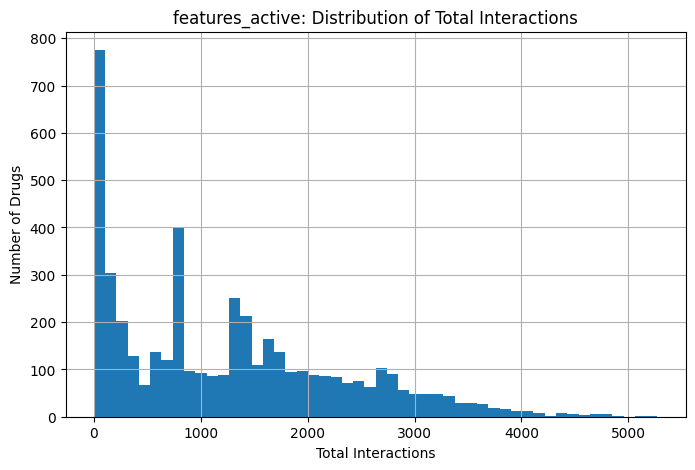

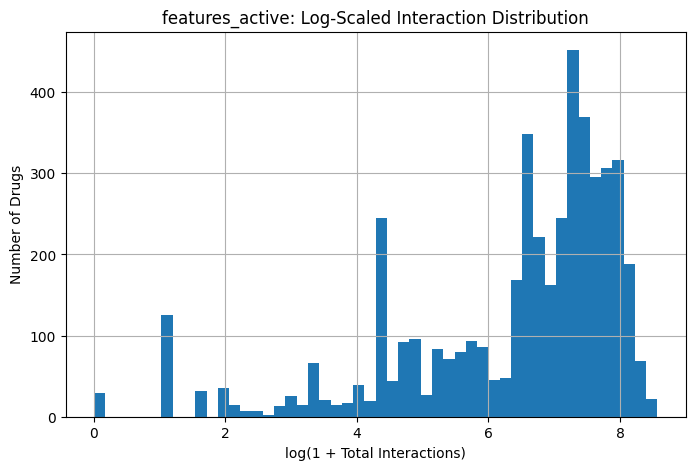

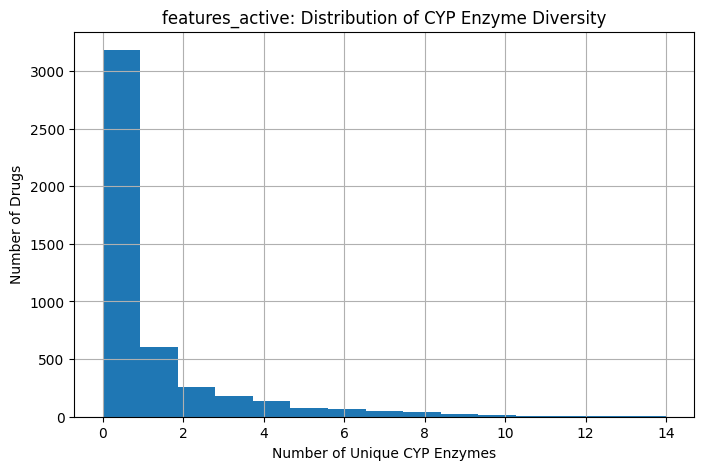

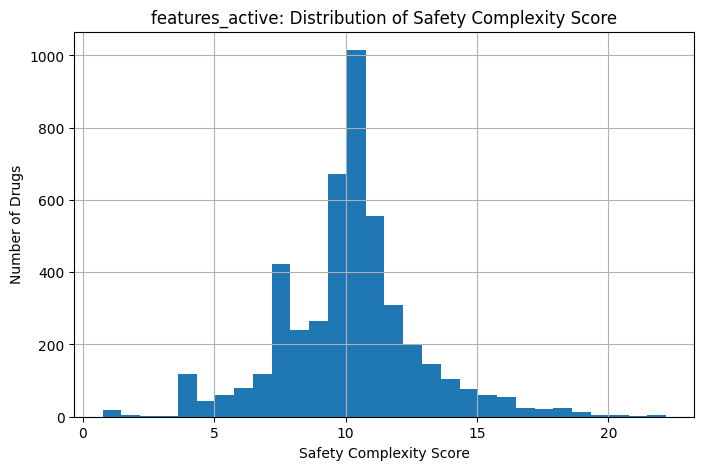

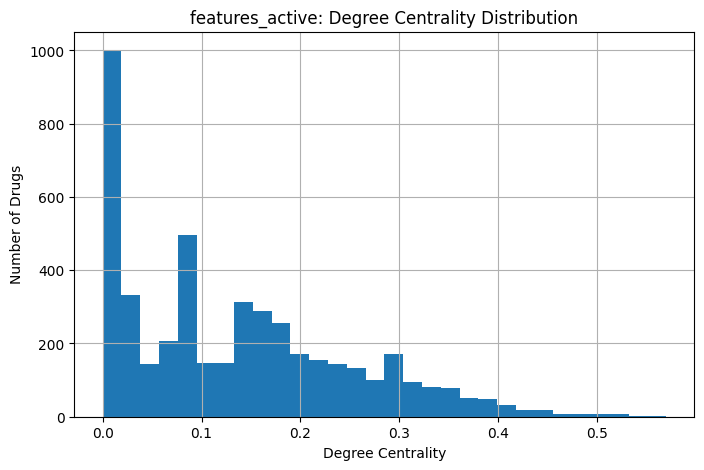

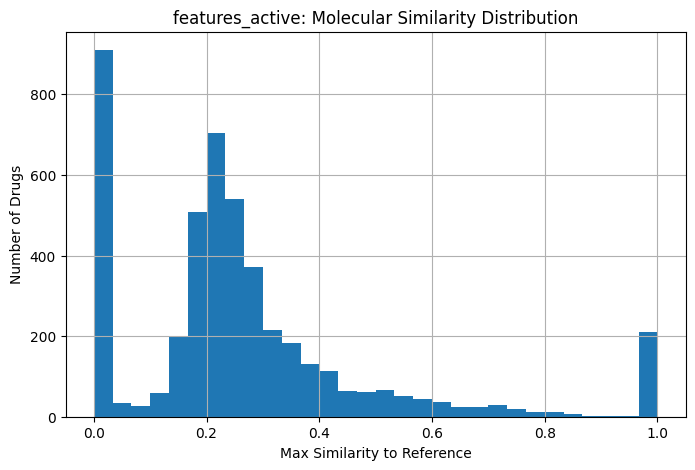

In [13]:

import numpy as np
import matplotlib.pyplot as plt

# Plot 1: Interaction distribution
plt.figure(figsize=(8, 5))
features_active["total_interactions"].hist(bins=50)
plt.xlabel("Total Interactions")
plt.ylabel("Number of Drugs")
plt.title("features_active: Distribution of Total Interactions")
plt.show()

# Plot 2: Log-scaled interaction distribution
plt.figure(figsize=(8, 5))
np.log1p(features_active["total_interactions"]).hist(bins=50)
plt.xlabel("log(1 + Total Interactions)")
plt.ylabel("Number of Drugs")
plt.title("features_active: Log-Scaled Interaction Distribution")
plt.show()

# Plot 3: CYP diversity
plt.figure(figsize=(8, 5))
features_active["n_unique_cyp"].hist(bins=15)
plt.xlabel("Number of Unique CYP Enzymes")
plt.ylabel("Number of Drugs")
plt.title("features_active: Distribution of CYP Enzyme Diversity")
plt.show()

# Plot 4: Safety complexity score
plt.figure(figsize=(8, 5))
features_active["safety_complexity_score"].hist(bins=30)
plt.xlabel("Safety Complexity Score")
plt.ylabel("Number of Drugs")
plt.title("features_active: Distribution of Safety Complexity Score")
plt.show()

# Plot 5: Degree centrality
plt.figure(figsize=(8, 5))
features_active["degree_centrality"].hist(bins=30)
plt.xlabel("Degree Centrality")
plt.ylabel("Number of Drugs")
plt.title("features_active: Degree Centrality Distribution")
plt.show()

# Plot 6: Similarity to reference panel
plt.figure(figsize=(8, 5))
features_active["max_similarity_to_reference"].hist(bins=30)
plt.xlabel("Max Similarity to Reference")
plt.ylabel("Number of Drugs")
plt.title("features_active: Molecular Similarity Distribution")
plt.show()



## 14. Final notes

This notebook now covers the full Task 3 checklist:

- **Molecular similarity features**: added through Morgan fingerprints + reference-panel Tanimoto similarity
- **Network graph features**: added interaction counts, partner counts, degree centrality, and betweenness centrality
- **CYP enzyme quality verification**: added normalized CYP features and token quality checks
- **Interaction severity categories**: added rule-based severity categories and per-drug severity aggregates
- **Enhanced save step**: saved as `drugbank_processed_enhanced.parquet`

The most important final output is:

`drugbank_processed_enhanced.parquet`
